# Task 1: GiantMIDI-Piano EDA and Markov Baseline
EDA and Markov baseline model for a MIDI pitch dataset.


## Dataset
To access data set go to https://github.com/bytedance/GiantMIDI-Piano and follow the disclaimer.md


In [4]:
import pickle
import random
from pathlib import Path
import pretty_midi
from collections import Counter, defaultdict
from math import exp, log
import matplotlib.pyplot as plt

BASE_DIR = Path(".")
MIDI_DIR = BASE_DIR / 'task1' / 'GiantMIDI-Piano-master' / 'midis'
DATA_FILE = BASE_DIR / 'task1' / "processed_pitch_data.pkl"
PLOTS_DIR = BASE_DIR / 'task1' / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SMOOTHING = 1.0

In [5]:
def get_midi_files(midi_dir, max_files=None):
    midi_files = sorted(Path(midi_dir).rglob('*.mid'))
    if max_files is not None:
        midi_files = midi_files[:max_files]
    return midi_files

def extract_pitch_sequence(midi_file):
    midi_data = pretty_midi.PrettyMIDI(str(midi_file))
    notes = []
    for instrument in midi_data.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            notes.append((note.start, note.pitch))
    notes.sort()
    return [pitch for _, pitch in notes]

def load_sequences(midi_files, min_notes=50):
    sequences, skipped = [], 0
    for midi_file in midi_files:
        try:
            pitches = extract_pitch_sequence(midi_file)
        except Exception as e:
            print(f'Could not read {midi_file.name}: {e}')
            skipped += 1; continue
        if len(pitches) < min_notes:
            skipped += 1; continue
        sequences.append(pitches)
    return sequences, skipped

def build_vocabulary(sequences):
    all_pitches = sorted(set(p for seq in sequences for p in seq))
    pitch_to_int = {p: i for i, p in enumerate(all_pitches)}
    int_to_pitch = {i: p for p, i in pitch_to_int.items()}
    return pitch_to_int, int_to_pitch

def make_training_examples(sequences, pitch_to_int, sequence_length=50):
    x, y = [], []
    for seq in sequences:
        enc = [pitch_to_int[p] for p in seq]
        for i in range(len(enc) - sequence_length):
            x.append(enc[i : i + sequence_length])
            y.append(enc[i + sequence_length])
    return x, y

def split_data(x, y, test_size=0.2, seed=42):
    pairs = list(zip(x, y))
    random.Random(seed).shuffle(pairs)
    split = int(len(pairs) * (1 - test_size))
    train, test = pairs[:split], pairs[split:]
    return ([p[0] for p in train], [p[1] for p in train],
            [p[0] for p in test],  [p[1] for p in test])


In [6]:
MAX_FILES       = 500
SEQUENCE_LENGTH = 50
MIN_NOTES       = 50
TEST_SIZE       = 0.2
SEED            = 42

midi_files = get_midi_files(MIDI_DIR, MAX_FILES)
sequences, skipped = load_sequences(midi_files, MIN_NOTES)

if len(sequences) == 0:
    raise ValueError('No usable MIDI files found. Check that the dataset is extracted to GiantMIDI-Piano-master/midis')

pitch_to_int, int_to_pitch = build_vocabulary(sequences)
x, y = make_training_examples(sequences, pitch_to_int, SEQUENCE_LENGTH)

if len(x) == 0:
    raise ValueError('No training examples created. Try a smaller SEQUENCE_LENGTH.')

x_train, y_train, x_test, y_test = split_data(x, y, TEST_SIZE, SEED)

processed_data = {
    'x_train': x_train, 'y_train': y_train,
    'x_test':  x_test,  'y_test':  y_test,
    'pitch_to_int':    pitch_to_int,
    'int_to_pitch':    int_to_pitch,
    'vocab_size':      len(pitch_to_int),
    'sequence_length': SEQUENCE_LENGTH,
    'midi_files_used': len(midi_files),
    'usable_songs':    len(sequences),
    'skipped_files':   skipped,
    'sequence_lengths': [len(s) for s in sequences],
    'pitch_counts':    dict(Counter(p for seq in sequences for p in seq)),
}

DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
with DATA_FILE.open('wb') as f:
    pickle.dump(processed_data, f)

print(f'MIDI files used:   {processed_data["midi_files_used"]}')
print(f'Usable songs:      {processed_data["usable_songs"]}')
print(f'Skipped files:     {processed_data["skipped_files"]}')
print(f'Vocabulary size:   {processed_data["vocab_size"]}')
print(f'Training examples: {len(x_train)}')
print(f'Testing examples:  {len(x_test)}')
print(f'Saved to:          {DATA_FILE}')

MIDI files used:   500
Usable songs:      499
Skipped files:     1
Vocabulary size:   84
Training examples: 1422685
Testing examples:  355672
Saved to:          task1/processed_pitch_data.pkl


In [7]:
def load_data(file=DATA_FILE):
    with Path(file).open("rb") as f:
        return pickle.load(f)

data = load_data()
print(f"MIDI files used: {data['midi_files_used']}")
print(f"Usable songs: {data['usable_songs']}")
print(f"Skipped files: {data['skipped_files']}")
print(f"Vocabulary size: {data['vocab_size']}")
print(f"Training examples: {len(data['x_train'])}")
print(f"Testing examples: {len(data['x_test'])}")

MIDI files used: 500
Usable songs: 499
Skipped files: 1
Vocabulary size: 84
Training examples: 1422685
Testing examples: 355672


## Task 1 - Part 1: Exploratory Data Analysis

### Pitch Distribution

In [8]:
def get_pitch_counts(data):
    """Return a Counter of MIDI pitch values from y_train + y_test."""
    if "pitch_counts" in data:
        return Counter(data["pitch_counts"])
    int_to_pitch = data["int_to_pitch"]
    encoded_targets = data["y_train"] + data["y_test"]
    return Counter(int_to_pitch[idx] for idx in encoded_targets)

pitch_counts = get_pitch_counts(data)
total_notes = sum(pitch_counts.values())
print(f"Total notes counted: {total_notes}")
print("\nTop 10 most common pitches:")
for pitch, count in pitch_counts.most_common(10):
    print(f"  MIDI {pitch}: {count}")

Total notes counted: 1803307

Top 10 most common pitches:
  MIDI 69: 60967
  MIDI 62: 58547
  MIDI 74: 56221
  MIDI 67: 56138
  MIDI 57: 54632
  MIDI 64: 52969
  MIDI 76: 51620
  MIDI 71: 51570
  MIDI 72: 51197
  MIDI 60: 50958


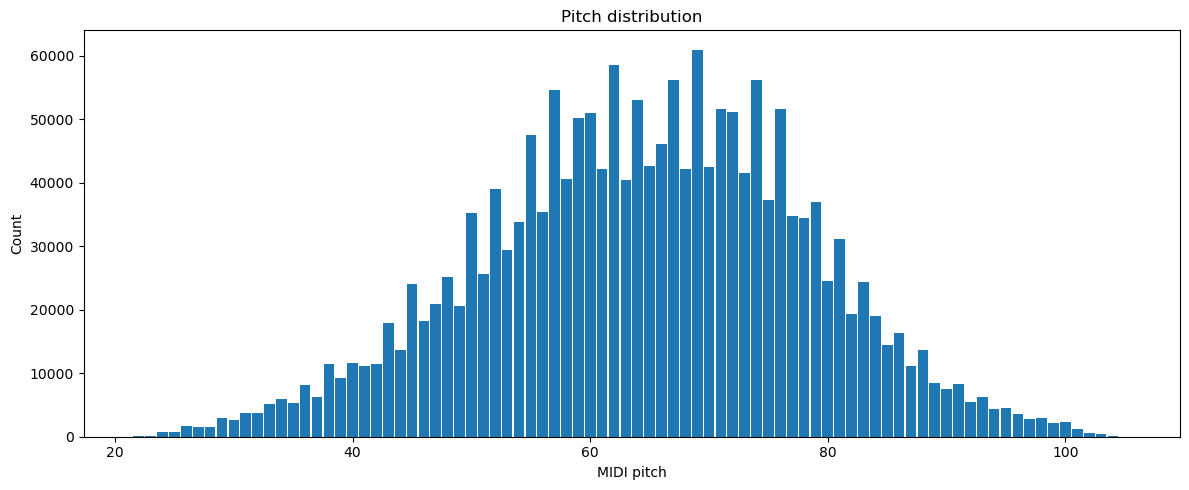

In [9]:
def plot_pitch_histogram(pitch_counts, output_file=None):
    pitches = sorted(pitch_counts)
    counts = [pitch_counts[p] for p in pitches]
    plt.figure(figsize=(12, 5))
    plt.bar(pitches, counts, width=0.9)
    plt.xlabel("MIDI pitch")
    plt.ylabel("Count")
    plt.title("Pitch distribution")
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()
    plt.close()

plot_pitch_histogram(pitch_counts, PLOTS_DIR / "pitch_distribution.png")

### Next-Note Interval Distribution

In [10]:
def get_interval_counts(data):
    int_to_pitch = data["int_to_pitch"]
    x_all = data["x_train"] + data["x_test"]
    y_all = data["y_train"] + data["y_test"]
    interval_counts = Counter()
    for sequence, target in zip(x_all, y_all):
        prev = int_to_pitch[sequence[-1]]
        nxt  = int_to_pitch[target]
        interval_counts[nxt - prev] += 1
    return interval_counts

interval_counts = get_interval_counts(data)
print("Top 10 most common next-note intervals:")
for interval, count in interval_counts.most_common(10):
    print(f"  {interval:+d} semitones: {count}")

Top 10 most common next-note intervals:
  +12 semitones: 107181
  -12 semitones: 107054
  +3 semitones: 77233
  -2 semitones: 71355
  -3 semitones: 67042
  +2 semitones: 61545
  +4 semitones: 60520
  +5 semitones: 57251
  -4 semitones: 53582
  +7 semitones: 48467


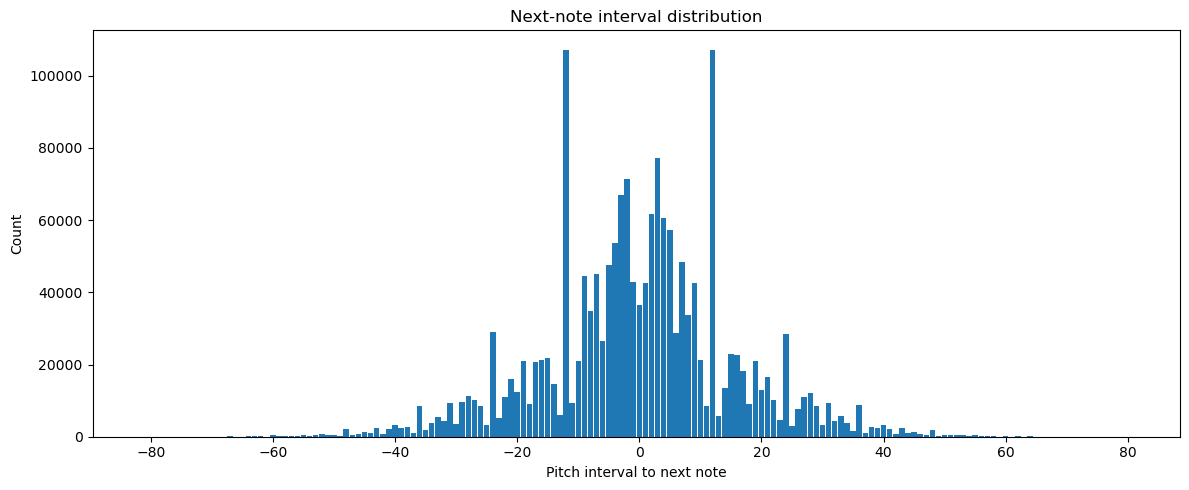

In [11]:
def plot_interval_histogram(interval_counts, output_file=None):
    intervals = sorted(interval_counts)
    counts = [interval_counts[i] for i in intervals]
    plt.figure(figsize=(12, 5))
    plt.bar(intervals, counts, width=0.9)
    plt.xlabel("Pitch interval to next note")
    plt.ylabel("Count")
    plt.title("Next-note interval distribution")
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()
    plt.close()

plot_interval_histogram(interval_counts, PLOTS_DIR / "next_note_intervals.png")

### Pitch Transition Heatmap

In [12]:
def get_transition_counts(data):
    int_to_pitch = data["int_to_pitch"]
    x_all = data["x_train"] + data["x_test"]
    y_all = data["y_train"] + data["y_test"]
    transition_counts = Counter()
    for sequence, target in zip(x_all, y_all):
        prev = int_to_pitch[sequence[-1]]
        nxt  = int_to_pitch[target]
        transition_counts[(prev, nxt)] += 1
    return transition_counts

transition_counts = get_transition_counts(data)

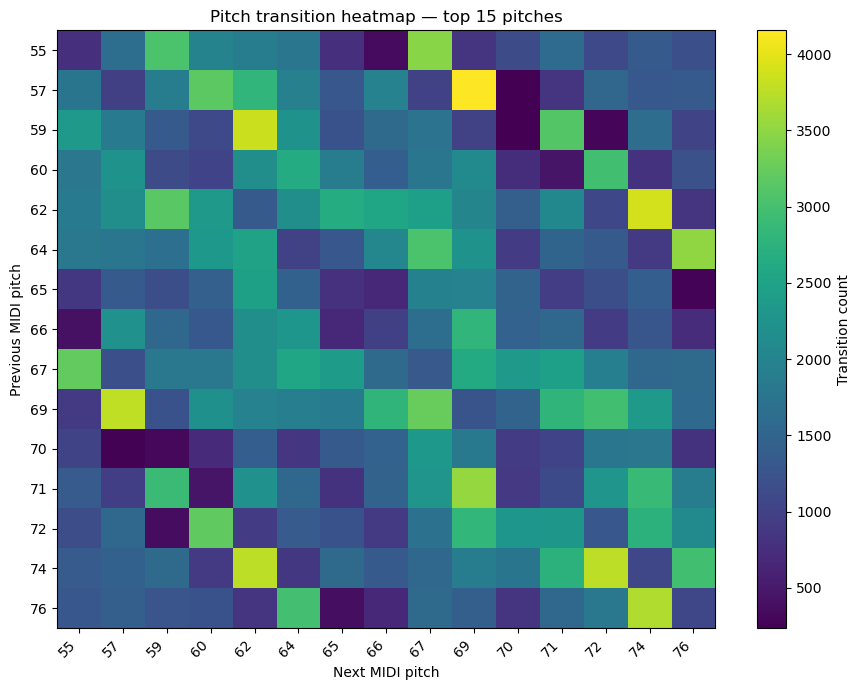

In [13]:
def plot_transition_heatmap(transition_counts, pitch_counts, output_file=None, top_n=15):
    top_pitches = sorted(p for p, _ in pitch_counts.most_common(top_n))
    pos = {p: i for i, p in enumerate(top_pitches)}
    matrix = [[0] * len(top_pitches) for _ in top_pitches]
    for (prev, nxt), count in transition_counts.items():
        if prev in pos and nxt in pos:
            matrix[pos[prev]][pos[nxt]] = count
    _, ax = plt.subplots(figsize=(9, 7))
    img = ax.imshow(matrix, aspect="auto")
    plt.colorbar(img, ax=ax, label="Transition count")
    ax.set_xticks(range(len(top_pitches)))
    ax.set_xticklabels(top_pitches, rotation=45, ha="right")
    ax.set_yticks(range(len(top_pitches)))
    ax.set_yticklabels(top_pitches)
    ax.set_xlabel("Next MIDI pitch")
    ax.set_ylabel("Previous MIDI pitch")
    ax.set_title(f"Pitch transition heatmap — top {top_n} pitches")
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()
    plt.close()

plot_transition_heatmap(transition_counts, pitch_counts, PLOTS_DIR / "pitch_transition_heatmap.png")

### Song Length Distribution

Shortest song:        92 notes
Longest song:         115481 notes
Average song length:  3613.8 notes
95th percentile:      11069 notes


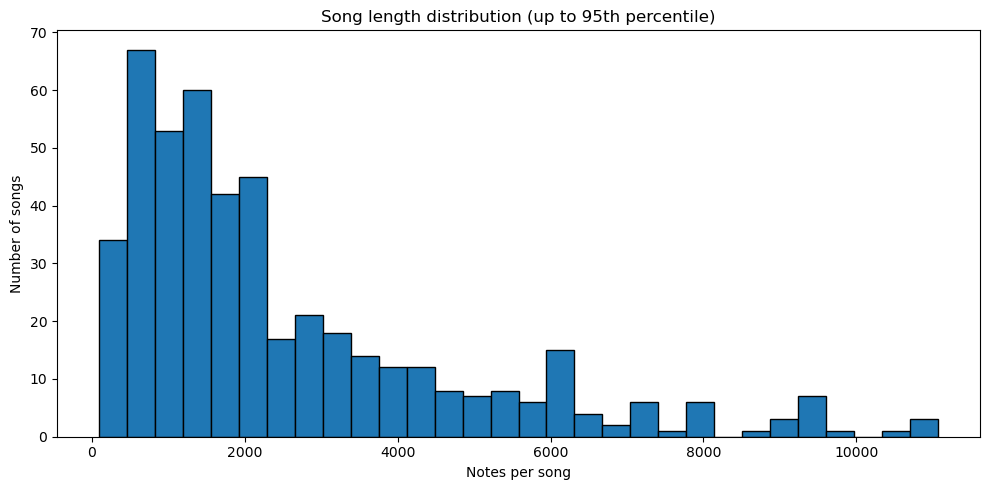

In [14]:
def percentile(values, pct):
    sv = sorted(values)
    return sv[round((pct / 100) * (len(sv) - 1))]

def plot_sequence_length_histogram(sequence_lengths, output_file=None, trim_pct=95):
    cutoff = percentile(sequence_lengths, trim_pct)
    trimmed = [l for l in sequence_lengths if l <= cutoff]
    plt.figure(figsize=(10, 5))
    plt.hist(trimmed, bins=30, edgecolor="black")
    plt.xlabel("Notes per song")
    plt.ylabel("Number of songs")
    plt.title(f"Song length distribution (up to {trim_pct}th percentile)")
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()
    plt.close()

sequence_lengths = data.get("sequence_lengths", [])
if sequence_lengths:
    print(f"Shortest song:        {min(sequence_lengths)} notes")
    print(f"Longest song:         {max(sequence_lengths)} notes")
    print(f"Average song length:  {sum(sequence_lengths)/len(sequence_lengths):.1f} notes")
    print(f"95th percentile:      {percentile(sequence_lengths, 95)} notes")
    plot_sequence_length_histogram(sequence_lengths, PLOTS_DIR / "song_lengths.png")
else:
    print("Song lengths not found in data. Re-run data.py to include song length metadata.")

## Task 1 - Part 2: Markov Baseline Model

In [15]:
def train_markov_model(x_train, y_train):
    transitions = defaultdict(Counter)
    for sequence, target in zip(x_train, y_train):
        transitions[sequence[-1]][target] += 1
    return transitions

markov_model = train_markov_model(data["x_train"], data["y_train"])
print(f"Distinct previous-pitch states seen during training: {len(markov_model)}")

Distinct previous-pitch states seen during training: 84


### Predict

In [16]:
def markov_predictions(model, x_test):
    best_next = {prev: counts.most_common(1)[0][0] for prev, counts in model.items()}
    return [best_next.get(seq[-1], 0) for seq in x_test]

preds = markov_predictions(markov_model, data["x_test"])

### Evaluate

In [17]:
def accuracy(predictions, targets):
    if not targets:
        return 0.0
    return sum(p == t for p, t in zip(predictions, targets)) / len(targets)

def perplexity(probabilities):
    if not probabilities:
        return 0.0
    mnll = -sum(log(p) for p in probabilities) / len(probabilities)
    return exp(mnll)

def markov_probabilities(model, x_test, y_test, vocab_size, smoothing=SMOOTHING):
    probs = []
    for seq, target in zip(x_test, y_test):
        counts = model.get(seq[-1])
        if counts is None:
            probs.append(1 / vocab_size)
        else:
            total = sum(counts.values()) + smoothing * vocab_size
            probs.append((counts[target] + smoothing) / total)
    return probs

probs = markov_probabilities(markov_model, data["x_test"], data["y_test"], data["vocab_size"])

print(f"Markov baseline accuracy:   {accuracy(preds, data['y_test']):.4f}")
print(f"Markov baseline perplexity: {perplexity(probs):.4f}")

Markov baseline accuracy:   0.0822
Markov baseline perplexity: 41.8311


# Task 1: Symbolic Music Generation

Pipeline: Config → Tokenize → Dataset → Model → Train → Generate

## 1. Install Dependencies

In [18]:
#!pip install pretty_midi torch torchvision torchaudio x-transformers einops tqdm matplotlib

## 2. Configuration

In [19]:
import os
from pathlib import Path

BASE_DIR = Path().resolve()
MIDI_DIR = BASE_DIR / 'task1' / "GiantMIDI-Piano-master" / "midis"
OUTPUT_DIR = BASE_DIR / 'task1' / "output"

MAX_SEQ_LEN = 512
PITCH_RANGE = (21, 109)
BEAT_RES = {(0, 4): 8, (4, 12): 4}

# model stuff
D_MODEL = 256
N_HEADS = 8
N_LAYERS = 6
D_FF = 1024
DROPOUT = 0.1

BATCH_SIZE = 4
EPOCHS = 100
LR = 3e-4
LR_WARMUP_STEPS = 2000
GRAD_CLIP = 1.0
SAVE_EVERY = 5
VAL_SPLIT = 0.1

GEN_LENGTH = 4096
GEN_TEMPERATURE = 1.0
GEN_TOP_K = 0
GEN_TOP_P = 0.9
GEN_REP_PENALTY = 1.2

SEED = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "checkpoints").mkdir(exist_ok=True)
(OUTPUT_DIR / "generated").mkdir(exist_ok=True)

print("config done")
print(f"midi dir: {MIDI_DIR.resolve()}")
print(f"output dir: {OUTPUT_DIR.resolve()}")


config done
midi dir: /home/ethan/Documents/CSE153/CSE153-Assignment-2/task1/GiantMIDI-Piano-master/midis
output dir: /home/ethan/Documents/CSE153/CSE153-Assignment-2/task1/output


## 3. Imports & Device

In [20]:
import random
import math
import time
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pretty_midi
from x_transformers import TransformerWrapper, Decoder

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")


device: cuda


## 4. Tokenizer
REMI - flat token sequence: Bar → Position → Pitch → Velocity → Duration

In [21]:
midi_files = list(MIDI_DIR.rglob("*.mid")) + list(MIDI_DIR.rglob("*.midi"))
print(f"Found {len(midi_files)} MIDI files")

Found 10860 MIDI files


In [22]:
TICKS_PER_BAR = 48
PITCH_MIN = 21
PITCH_MAX = 108
N_VELOCITY_BINS = 32
N_DURATION_BINS = 64
N_TEMPO_BINS = 32
TEMPO_MIN = 40.0
TEMPO_MAX = 240.0
MAX_DURATION_BEATS = 8.0

def _build_vocab():
    vocab = {}
    idx = 0
    for tok in ["PAD", "BOS", "EOS", "BAR"]:
        vocab[tok] = idx
        idx += 1
    for i in range(TICKS_PER_BAR):
        vocab[f"POSITION_{i}"] = idx
        idx += 1
    for p in range(PITCH_MIN, PITCH_MAX + 1):
        vocab[f"PITCH_{p}"] = idx
        idx += 1
    for v in range(N_VELOCITY_BINS):
        vocab[f"VELOCITY_{v}"] = idx
        idx += 1
    for d in range(N_DURATION_BINS):
        vocab[f"DURATION_{d}"] = idx
        idx += 1
    for t in range(N_TEMPO_BINS):
        vocab[f"TEMPO_{t}"] = idx
        idx += 1
    return vocab

vocab = _build_vocab()
vocab_inv = {v: k for k, v in vocab.items()}
PAD_ID = vocab["PAD"]
BOS_ID = vocab["BOS"]
EOS_ID = vocab["EOS"]
VOCAB_SIZE = len(vocab)

print(f"vocab size: {VOCAB_SIZE}")
print(f"token types: {set(k.split('_')[0] for k in vocab)}")

def encode_midi(pm):
    notes = []
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        for n in inst.notes:
            if PITCH_MIN <= n.pitch <= PITCH_MAX:
                notes.append(n)
    if not notes:
        return []

    t0 = min(n.start for n in notes)
    notes = sorted(notes, key=lambda n: n.start)
    tempo_times, tempos = pm.get_tempo_changes()
    if len(tempos) == 0:
        tempos = [120.0]

    def get_tempo_at(t):
        if len(tempo_times) <= 1:
            return tempos[0]
        idx = np.searchsorted(tempo_times, t + t0, side="right") - 1
        return tempos[max(0, idx)]

    def quantize_velocity(v):
        return min(N_VELOCITY_BINS - 1, int(v / 128 * N_VELOCITY_BINS))

    def quantize_duration(dur_beats):
        dur_beats = max(0.0, min(MAX_DURATION_BEATS, dur_beats))
        return min(N_DURATION_BINS - 1, int(dur_beats / MAX_DURATION_BEATS * N_DURATION_BINS))

    def quantize_tempo(bpm):
        bpm = max(TEMPO_MIN, min(TEMPO_MAX, bpm))
        return min(N_TEMPO_BINS - 1, int((bpm - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN) * N_TEMPO_BINS))

    tokens = [BOS_ID]
    current_bar = -1

    for note in notes:
        t = note.start - t0
        tempo = get_tempo_at(t)
        spb = 60.0 / tempo
        spbar = spb * 4.0

        bar = int(t / spbar)
        pos_f = (t % spbar) / spbar
        pos = min(TICKS_PER_BAR - 1, int(pos_f * TICKS_PER_BAR))

        dur_beats = (note.end - note.start) / spb

        while current_bar < bar:
            current_bar += 1
            tokens.append(vocab["BAR"])
            tokens.append(vocab[f"TEMPO_{quantize_tempo(tempo)}"])

        tokens.append(vocab[f"POSITION_{pos}"])
        tokens.append(vocab[f"PITCH_{note.pitch}"])
        tokens.append(vocab[f"VELOCITY_{quantize_velocity(note.velocity)}"])
        tokens.append(vocab[f"DURATION_{quantize_duration(dur_beats)}"])

    tokens.append(EOS_ID)
    return tokens

def decode_tokens(token_ids, default_tempo=120.0):
    pm = pretty_midi.PrettyMIDI(initial_tempo=default_tempo)
    inst = pretty_midi.Instrument(program=0, name="Piano")

    tempo = default_tempo
    spb = 60.0 / tempo
    bar = -1
    pos = 0
    pitch = None
    velocity = 64
    t_bar = 0.0

    toks = [vocab_inv.get(i, "?") for i in token_ids
            if i not in (PAD_ID, BOS_ID, EOS_ID)]

    i = 0
    while i < len(toks):
        tok = toks[i]
        if tok == "BAR":
            if bar >= 0:
                t_bar += spb * 4.0
            bar += 1
            pitch = None
        elif tok.startswith("TEMPO_"):
            bucket = int(tok.split("_")[1])
            tempo = TEMPO_MIN + (bucket / N_TEMPO_BINS) * (TEMPO_MAX - TEMPO_MIN)
            spb = 60.0 / tempo
        elif tok.startswith("POSITION_"):
            pos = int(tok.split("_")[1])
        elif tok.startswith("PITCH_"):
            pitch = int(tok.split("_")[1])
        elif tok.startswith("VELOCITY_"):
            velocity = int(int(tok.split("_")[1]) / N_VELOCITY_BINS * 127)
        elif tok.startswith("DURATION_") and pitch is not None:
            bucket = int(tok.split("_")[1])
            dur_beats = (bucket / N_DURATION_BINS) * MAX_DURATION_BEATS
            t_start = t_bar + (pos / TICKS_PER_BAR) * spb * 4.0
            t_end = t_start + max(0.05, dur_beats * spb)
            inst.notes.append(pretty_midi.Note(
                velocity=min(127, max(1, velocity)),
                pitch=pitch,
                start=max(0.0, t_start),
                end=t_end,
            ))
            pitch = None
        i += 1

    inst.notes.sort(key=lambda n: n.start)
    pm.instruments.append(inst)
    return pm


vocab size: 268
token types: {'PITCH', 'BAR', 'EOS', 'PAD', 'TEMPO', 'DURATION', 'POSITION', 'BOS', 'VELOCITY'}


In [23]:
# To retokenize: import os; os.remove(OUTPUT_DIR / "tokens.pkl")

TOKEN_CACHE = OUTPUT_DIR / "tokens.pkl"

if TOKEN_CACHE.exists():
    with open(TOKEN_CACHE, "rb") as f:
        all_token_sequences = pickle.load(f)
    print(f"loaded {len(all_token_sequences)} cached sequences")

else:
    print("tokenizing...")
    all_token_sequences = []
    skipped_short = 0
    skipped_error = 0
    MIN_TOKENS = 64

    for midiPath in tqdm(midi_files):
        try:
            pm = pretty_midi.PrettyMIDI(str(midiPath))
            ids = encode_midi(pm)
            if len(ids) >= MIN_TOKENS:
                all_token_sequences.append(ids)
            else:
                skipped_short += 1
        except Exception as e:
            skipped_error += 1

    print(f"files: {len(midi_files)}")
    print(f"sequences kept: {len(all_token_sequences)}")
    print(f"skipped short: {skipped_short}")
    print(f"skipped error: {skipped_error}")

    if len(all_token_sequences) == 0:
        raise RuntimeError("no sequences extracted")

    with open(TOKEN_CACHE, "wb") as f:
        pickle.dump(all_token_sequences, f)
    print(f"cached to {TOKEN_CACHE}")

lengths = [len(s) for s in all_token_sequences]

print(f"total sequences: {len(lengths)}")
print(f"avg length: {np.mean(lengths):.0f}")
print(f"total tokens: {sum(lengths):,}")

print(f"sample tokens from seq 0:")
print([vocab_inv.get(i, "?") for i in all_token_sequences[0][:20]])


tokenizing...


  0%|          | 0/10860 [00:00<?, ?it/s]

files: 10860
sequences kept: 10858
skipped short: 2
skipped error: 0


cached to /home/ethan/Documents/CSE153/CSE153-Assignment-2/task1/output/tokens.pkl
total sequences: 10858
avg length: 14663
total tokens: 159,207,330
sample tokens from seq 0:
['BOS', 'BAR', 'TEMPO_12', 'POSITION_0', 'PITCH_81', 'VELOCITY_18', 'DURATION_17', 'POSITION_13', 'PITCH_72', 'VELOCITY_14', 'DURATION_13', 'POSITION_21', 'PITCH_77', 'VELOCITY_16', 'DURATION_15', 'POSITION_28', 'PITCH_69', 'VELOCITY_16', 'DURATION_11', 'POSITION_33']


In [8]:
# subsample because my gpu cannot handle a lot
import random as _random
MAX_SEQUENCES = 3000

if len(all_token_sequences) > MAX_SEQUENCES:
    _random.seed(SEED)
    all_token_sequences = _random.sample(all_token_sequences, MAX_SEQUENCES)
    print(f"subsampled to {len(all_token_sequences)}")
else:
    print(f"using all {len(all_token_sequences)} sequences")


Subsampled to 3000 sequences
Total tokens: 43,382,636


## 5. Dataset

In [9]:
class MusicDataset(Dataset):

    def __init__(self, sequences, seq_len, pad_id, bos_id, eos_id):
        self.seq_len = seq_len
        self.pad_id = pad_id
        self.bos_id = bos_id
        self.eos_id = eos_id
        self.chunks = []

        for seq in sequences:
            seq = [bos_id] + seq + [eos_id]
            stride = seq_len  # no overlap
            for start in range(0, max(1, len(seq) - seq_len), stride):
                chunk = seq[start : start + seq_len + 1]
                self.chunks.append(chunk)

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        chunk = self.chunks[idx]
        pad_len = (self.seq_len + 1) - len(chunk)
        chunk = chunk + [self.pad_id] * pad_len

        ids = torch.tensor(chunk, dtype=torch.long)
        x = ids[:-1]
        y = ids[1:]
        return x, y


full_dataset = MusicDataset(all_token_sequences, MAX_SEQ_LEN, PAD_ID, BOS_ID, EOS_ID)

val_size = max(1, int(len(full_dataset) * VAL_SPLIT))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    pin_memory=(device.type == "cuda"), num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    pin_memory=(device.type == "cuda"), num_workers=0)

print(f"total chunks: {len(full_dataset)}")
print(f"train: {train_size}, val: {val_size}")
print(f"train batches: {len(train_loader)}")


Total chunks   : 83237
Training chunks: 74914
Val chunks     : 8323
Train batches  : 18729

Sample x shape : torch.Size([512])
Sample y shape : torch.Size([512])


## 6. Model

In [10]:
model = TransformerWrapper(
    num_tokens=VOCAB_SIZE,
    max_seq_len=MAX_SEQ_LEN,
    use_abs_pos_emb=False,
    attn_layers=Decoder(
        dim=D_MODEL,
        depth=N_LAYERS,
        heads=N_HEADS,
        ff_mult=D_FF // D_MODEL,
        attn_dropout=DROPOUT,
        ff_dropout=DROPOUT,
        rel_pos_bias=True
    )
).to(device)


Model parameters: 6,439,936 (6.4M)
Vocab size      : 268


## 7. Training Setup

In [11]:
optimizer = AdamW(model.parameters(), lr=LR, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)
total_steps = EPOCHS * len(train_loader)
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=LR * 0.01)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

def warmup_lr(step):
    if step < LR_WARMUP_STEPS:
        return float(step + 1) / LR_WARMUP_STEPS
    return 1.0

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_lr)
global_step = 0


Total training steps: 1,872,900
Optimizer: AdamW (lr=0.0003, wd=0.01)
Scheduler: CosineAnnealingLR (T_max=1872900)
Loss: CrossEntropy (ignoring PAD id=0)


## 8. Training

In [12]:
def train_epoch(model, loader, optimizer, criterion, device, global_step):
    model.train()
    total_loss = 0.0
    total_tokens = 0
    correct = 0

    pbar = tqdm(loader, desc="Train", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        if global_step < LR_WARMUP_STEPS:
            warmup_scheduler.step()
        else:
            scheduler.step()
        optimizer.step()
        global_step += 1

        mask = (y != PAD_ID)
        correct += (logits.argmax(dim=-1)[mask] == y[mask]).sum().item()
        n_tokens = mask.sum().item()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    return total_loss / max(total_tokens, 1), correct / max(total_tokens, 1), global_step


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    correct = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
        mask = (y != PAD_ID)
        correct += (logits.argmax(dim=-1)[mask] == y[mask]).sum().item()
        n = mask.sum().item()
        total_loss += loss.item() * n
        total_tokens += n
    return total_loss / max(total_tokens, 1), correct / max(total_tokens, 1)


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
global_step = 0

print(f"starting training for {EPOCHS} epochs...")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc, global_step = train_epoch(model, train_loader, optimizer, criterion, device, global_step)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - t0
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"epoch {epoch}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | train_acc={train_acc:.3f} val_acc={val_acc:.3f} | ppl={math.exp(val_loss):.1f} | {elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": val_loss,
            "history": history,
            "config": {
                "vocab_size": VOCAB_SIZE, "d_model": D_MODEL,
                "n_heads": N_HEADS, "n_layers": N_LAYERS,
                "d_ff": D_FF, "max_len": MAX_SEQ_LEN, "pad_id": PAD_ID
            }
        }, OUTPUT_DIR / "checkpoints" / "best_model.pt")
        print(f"  -> new best saved (val_loss={val_loss:.4f})")

    if epoch % SAVE_EVERY == 0:
        ckptPath = OUTPUT_DIR / "checkpoints" / f"epoch_{epoch:04d}.pt"
        torch.save({"epoch": epoch, "model_state": model.state_dict()}, ckptPath)

print(f"done. best val loss: {best_val_loss:.4f}")


Epoch  41/100 | train_loss=1.6795 val_loss=1.6941 | train_acc=0.455 val_acc=0.453 | ppl=5.4 | 1014.8s


Train:   0%|          | 0/18729 [00:00<?, ?it/s]

Epoch  42/100 | train_loss=1.6778 val_loss=1.6925 | train_acc=0.455 val_acc=0.453 | ppl=5.4 | 1014.8s
  New best model saved (val_loss=1.6925)


Train:   0%|          | 0/18729 [00:00<?, ?it/s]

Epoch  43/100 | train_loss=1.6762 val_loss=1.6925 | train_acc=0.455 val_acc=0.453 | ppl=5.4 | 1014.8s


...

Train:   0%|          | 0/18729 [00:00<?, ?it/s]

Epoch  77/100 | train_loss=1.6186 val_loss=1.6769 | train_acc=0.471 val_acc=0.458 | ppl=5.3 | 1081.7s


Train:   0%|          | 0/18729 [00:00<?, ?it/s]

Epoch  78/100 | train_loss=1.6171 val_loss=1.6777 | train_acc=0.471 val_acc=0.458 | ppl=5.4 | 1103.7s


Train:   0%|          | 0/18729 [00:00<?, ?it/s]

## 9. Training Curves

In [4]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(epochs, history["val_loss"], label="Val", color="coral")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a*100 for a in history["train_acc"]], label="Train", color="steelblue")
    axes[1].plot(epochs, [a*100 for a in history["val_acc"]], label="Val", color="coral")
    axes[1].set_title("Accuracy (%)")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, [math.exp(l) for l in history["val_loss"]], color="mediumpurple")
    axes[2].set_title("Val Perplexity")
    axes[2].set_xlabel("Epoch")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_history(history)


NameError: name 'history' is not defined

## 10. Load Best Model

In [5]:
ckpt = torch.load(OUTPUT_DIR / "checkpoints" / "best_model.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"loaded best model from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")


NameError: name 'torch' is not defined

## 11. Generate

In [ ]:
@torch.no_grad()
def generate(model, bos_id, eos_id, device, prompt_ids=None, max_new_tokens=512,
             temperature=1.0, top_k=0, top_p=0.9, rep_penalty=1.2, rep_window=128):
    model.eval()

    if prompt_ids is None:
        prompt_ids = [bos_id]

    ids = torch.tensor([prompt_ids], dtype=torch.long, device=device)

    generated = []
    for _ in tqdm(range(max_new_tokens), desc="Generating", leave=True):
        context = ids[:, -MAX_SEQ_LEN:]
        logits = model(context)
        logits = logits[0, -1, :]

        if rep_penalty != 1.0:
            recent = ids[0, -rep_window:].tolist()
            for tok_id in set(recent):
                if logits[tok_id] > 0:
                    logits[tok_id] /= rep_penalty
                else:
                    logits[tok_id] *= rep_penalty

        logits = logits / max(temperature, 1e-8)

        if top_k > 0:
            kth_val = torch.topk(logits, top_k).values[-1]
            logits = logits.masked_fill(logits < kth_val, float("-inf"))

        if 0.0 < top_p < 1.0:
            sorted_logits, sorted_idx = torch.sort(logits, descending=True)
            cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            remove_mask = cum_probs - F.softmax(sorted_logits, dim=-1) > top_p
            sorted_logits[remove_mask] = float("-inf")
            logits = torch.zeros_like(logits).scatter_(0, sorted_idx, sorted_logits)

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        ids = torch.cat([ids, next_id.unsqueeze(0)], dim=1)
        tokenInt = next_id.item()
        generated.append(tokenInt)
        if tokenInt == eos_id:
            break

    return generated


In [ ]:
generated_ids = generate(
    model,
    bos_id=BOS_ID,
    eos_id=EOS_ID,
    device=device,
    prompt_ids=None,
    max_new_tokens=GEN_LENGTH,
    temperature=GEN_TEMPERATURE,
    top_k=GEN_TOP_K,
    top_p=GEN_TOP_P,
    rep_penalty=GEN_REP_PENALTY
)

out_path = OUTPUT_DIR / "generated" / "symbolic_unconditioned.mid"
out_path.parent.mkdir(exist_ok=True)

pm_out = decode_tokens(generated_ids)
n_notes = len(pm_out.instruments[0].notes) if pm_out.instruments else 0

if n_notes == 0:
    print("no notes generated, something probably went wrong")
else:
    pm_out.write(str(out_path))
    dur = pm_out.get_end_time()
    print(f"saved to: {out_path}")
    print(f"notes: {n_notes}, duration: {dur:.1f}s")


# Task 2: Symbolic Conditioned Generation

## Dataset
To access dataset go to https://github.com/czhuang/JSB-Chorales-dataset and download the files or clone the repo


## Imports & Configuration

In [22]:
import os
import pickle
import numpy as np
import collections
import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = './task2/JSB-Chorales-dataset-master'

## 1. Load Data

In [23]:
def load_data():
    """Load the JSB Chorales dataset from pickle and print basic split info."""
    print("Loading JSB Chorales dataset...")

    pkl_path = os.path.join(DATA_PATH, 'jsb-chorales-16th.pkl')
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    for split in ['train', 'valid', 'test']:
        print(f"  {split}: {len(data[split])} chorales")

    first = data['train'][0]
    print(f"  First training chorale length: {len(first)} timesteps, {len(first[0])} voices")

    return data


raw = load_data()

Loading JSB Chorales dataset...
  train: 229 chorales
  valid: 76 chorales
  test: 77 chorales
  First training chorale length: 192 timesteps, 4 voices


## 2. Parse Chorales

In [24]:
def parse_chorales(data_dict):
    """Extract (melody_note, chord) pairs from each chorale across all splits."""
    print("Parsing chorales...")

    parsed = {}
    for split in ['train', 'valid', 'test']:
        split_sequences = []
        for chorale in data_dict[split]:
            sequence = []
            for timestep in chorale:
                if len(timestep) < 4:
                    continue
                melody_note = int(timestep[0])
                chord = frozenset(int(v) for v in timestep[1:] if v != 0)
                sequence.append((melody_note, chord))
            split_sequences.append(sequence)
        parsed[split] = split_sequences

    print("  First 5 timesteps of first training chorale:")
    for i, (note, chord) in enumerate(parsed['train'][0][:5]):
        print(f"    t={i}  melody={note}  chord={set(chord)}")

    return parsed


parsed = parse_chorales(raw)

Parsing chorales...
  First 5 timesteps of first training chorale:
    t=0  melody=74  chord={65, 58, 70}
    t=1  melody=74  chord={65, 58, 70}
    t=2  melody=74  chord={65, 58, 70}
    t=3  melody=74  chord={65, 58, 70}
    t=4  melody=75  chord={58, 70, 55}


## 3. Build Vocabularies

In [25]:
def build_vocabularies(parsed_data):
    """Build note and chord vocabularies from training set only, with PAD and UNK tokens."""
    print("Building vocabularies...")

    all_notes = set()
    all_chords = set()
    for seq in parsed_data['train']:
        for melody_note, chord in seq:
            all_notes.add(melody_note)
            all_chords.add(chord)

    note_to_idx = {'PAD': 0, 'UNK': 1}
    for note in sorted(all_notes):
        note_to_idx[note] = len(note_to_idx)
    idx_to_note = {idx: note for note, idx in note_to_idx.items()}

    chord_to_idx = {'PAD': 0, 'UNK': 1}
    for chord in sorted(all_chords):
        chord_to_idx[chord] = len(chord_to_idx)
    idx_to_chord = {idx: chord for chord, idx in chord_to_idx.items()}

    print(f"  Note vocabulary size:  {len(note_to_idx)}  (includes PAD and UNK)")
    print(f"  Chord vocabulary size: {len(chord_to_idx)}  (includes PAD and UNK)")

    return note_to_idx, idx_to_note, chord_to_idx, idx_to_chord


note_to_idx, idx_to_note, chord_to_idx, idx_to_chord = build_vocabularies(parsed)

Building vocabularies...
  Note vocabulary size:  24  (includes PAD and UNK)
  Chord vocabulary size: 1660  (includes PAD and UNK)


## 4. Encode Sequences

In [26]:
def encode_sequences(parsed_data, note_to_idx, chord_to_idx):
    """Convert (melody_note, chord) pairs to (note_idx, chord_idx) integer index pairs."""
    print("Encoding sequences...")

    encoded = {}
    for split in ['train', 'valid', 'test']:
        split_sequences = []
        for seq in parsed_data[split]:
            encoded_seq = []
            for melody_note, chord in seq:
                note_idx = note_to_idx.get(melody_note, note_to_idx['UNK'])
                chord_idx = chord_to_idx.get(chord, chord_to_idx['UNK'])
                encoded_seq.append((note_idx, chord_idx))
            split_sequences.append(encoded_seq)
        encoded[split] = split_sequences

    total = sum(len(seq) for seq in encoded['train'])
    print(f"  Encoded {len(encoded['train'])} train chorales ({total} timesteps total)")

    return encoded


encoded = encode_sequences(parsed, note_to_idx, chord_to_idx)

Encoding sequences...
  Encoded 229 train chorales (55097 timesteps total)


## 5. Exploratory Data Analysis

In [27]:
os.makedirs('task2/eda_plots', exist_ok=True)

train = parsed['train']

all_notes   = [note  for seq in train for note, _  in seq]
all_chords  = [chord for seq in train for _,    chord in seq]
lengths     = [len(seq) for seq in train]

note_counts  = collections.Counter(all_notes)
chord_counts = collections.Counter(all_chords)

most_common_note  = note_counts.most_common(1)[0][0]
most_common_chord = chord_counts.most_common(1)[0][0]
print(f"Most common melody note : MIDI {most_common_note}")
print(f"Most common chord       : {set(most_common_chord)}")

total_timesteps = len(all_chords)
top10 = chord_counts.most_common(10)
df_top10 = pd.DataFrame({
    'chord': [str(set(c)) for c, _ in top10],
    'count': [cnt for _, cnt in top10],
    'pct':   [f'{cnt / total_timesteps * 100:.1f}%' for _, cnt in top10],
})
print("\nTop 10 chords:")
display(df_top10)

Most common melody note : MIDI 69
Most common chord       : {66, 50, 62}

Top 10 chords:


,chord,count,pct
0,"{66, 50, 62}",1140,2.1%
1,"{43, 59, 62}",1105,2.0%
2,"{67, 62, 55}",1044,1.9%
3,"{57, 50, 62}",853,1.5%
4,"{57, 66, 50}",703,1.3%
5,"{64, 48, 60}",688,1.2%
6,"{64, 45, 61}",630,1.1%
7,"{64, 59, 52}",630,1.1%
8,"{64, 68, 52}",614,1.1%
9,"{65, 60, 53}",564,1.0%


### Melody Note Distribution

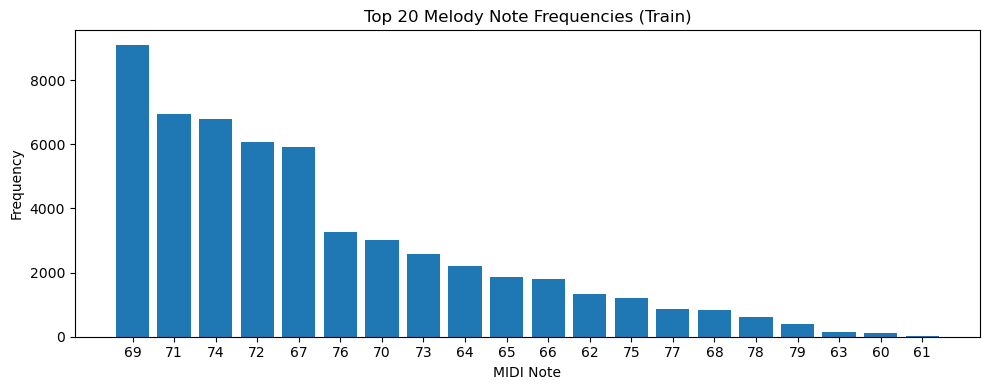

In [28]:
top_notes = note_counts.most_common(20)
notes, note_freqs = zip(*top_notes)

_, ax = plt.subplots(figsize=(10, 4))
ax.bar([str(n) for n in notes], note_freqs)
ax.set_xlabel('MIDI Note')
ax.set_ylabel('Frequency')
ax.set_title('Top 20 Melody Note Frequencies (Train)')
plt.tight_layout()
plt.savefig('task2/eda_plots/melody_note_freq.png')
plt.show()

### Chord Distribution

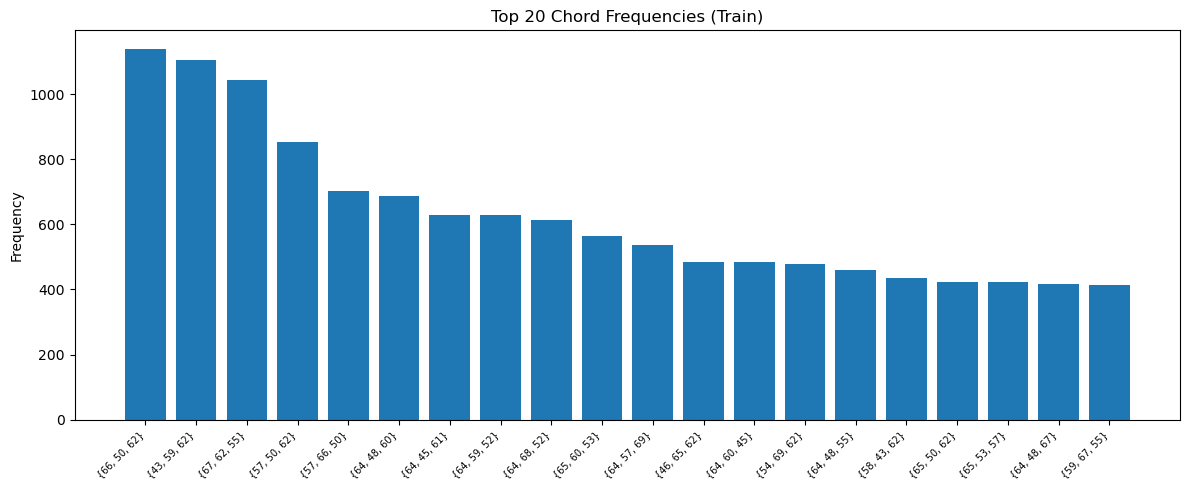

In [29]:
top_chords   = chord_counts.most_common(20)
chord_labels = [str(set(c)) for c, _ in top_chords]
chord_freqs  = [f for _, f in top_chords]

_, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(chord_labels)), chord_freqs)
ax.set_xticks(range(len(chord_labels)))
ax.set_xticklabels(chord_labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Frequency')
ax.set_title('Top 20 Chord Frequencies (Train)')
plt.tight_layout()
plt.savefig('task2/eda_plots/chord_freq.png')
plt.show()

### Chorale Length Distribution

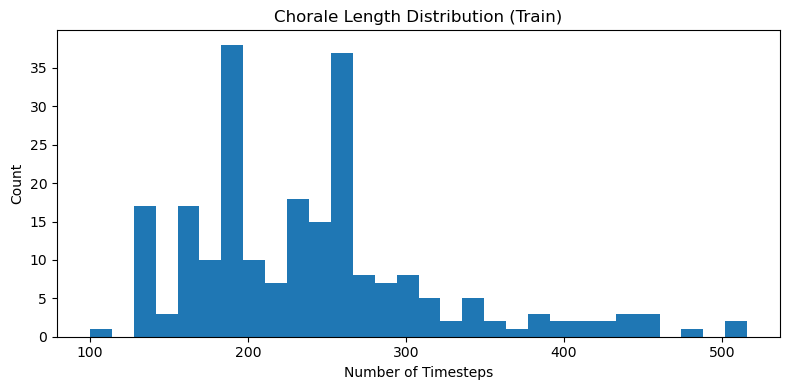

In [30]:
_, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=30)
ax.set_xlabel('Number of Timesteps')
ax.set_ylabel('Count')
ax.set_title('Chorale Length Distribution (Train)')
plt.tight_layout()
plt.savefig('task2/eda_plots/chorale_lengths.png')
plt.show()

### Average Melody Note by Position

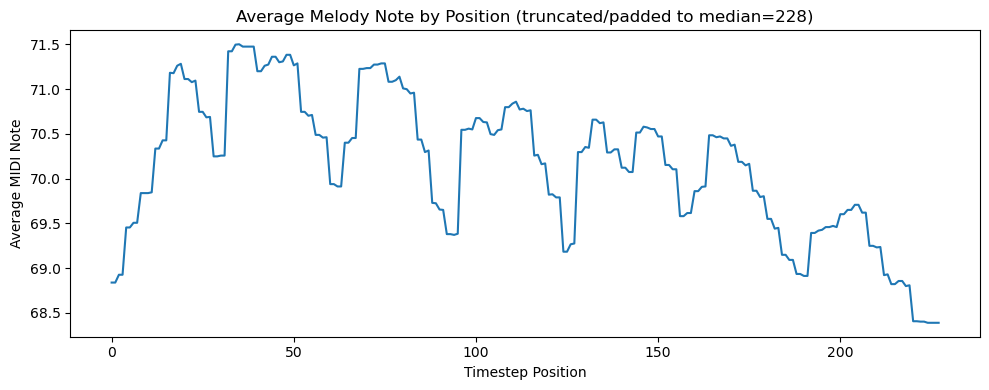

In [31]:
median_len = int(np.median(lengths))
truncated  = []
for seq in train:
    notes_only = [note for note, _ in seq]
    if len(notes_only) >= median_len:
        truncated.append(notes_only[:median_len])
    else:
        padded = notes_only + [notes_only[-1]] * (median_len - len(notes_only))
        truncated.append(padded)

avg_by_pos = np.mean(truncated, axis=0)

_, ax = plt.subplots(figsize=(10, 4))
ax.plot(avg_by_pos)
ax.set_xlabel('Timestep Position')
ax.set_ylabel('Average MIDI Note')
ax.set_title(f'Average Melody Note by Position (truncated/padded to median={median_len})')
plt.tight_layout()
plt.savefig('task2/eda_plots/avg_melody_by_position.png')
plt.show()

### Note Transition Heatmap

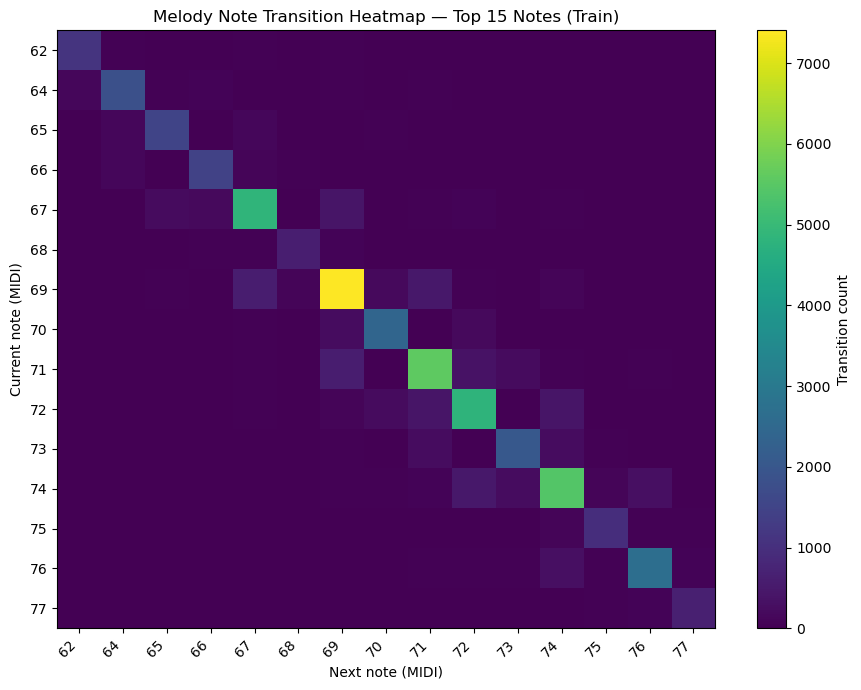

In [32]:
top15_notes        = [note for note, _ in note_counts.most_common(15)]
note_set           = set(top15_notes)
transition_counts  = collections.Counter()

for seq in train:
    notes_only = [note for note, _ in seq]
    for curr, nxt in zip(notes_only, notes_only[1:]):
        if curr in note_set and nxt in note_set:
            transition_counts[(curr, nxt)] += 1

sorted_notes = sorted(top15_notes)
note_pos     = {note: i for i, note in enumerate(sorted_notes)}
matrix       = np.zeros((len(sorted_notes), len(sorted_notes)))
for (curr, nxt), cnt in transition_counts.items():
    matrix[note_pos[curr], note_pos[nxt]] = cnt

_, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matrix, aspect='auto')
plt.colorbar(im, ax=ax, label='Transition count')
ax.set_xticks(range(len(sorted_notes)))
ax.set_yticks(range(len(sorted_notes)))
ax.set_xticklabels(sorted_notes, rotation=45, ha='right')
ax.set_yticklabels(sorted_notes)
ax.set_xlabel('Next note (MIDI)')
ax.set_ylabel('Current note (MIDI)')
ax.set_title('Melody Note Transition Heatmap — Top 15 Notes (Train)')
plt.tight_layout()
plt.savefig('task2/eda_plots/note_transitions.png')
plt.show()

### Chord Analysis

  valid: 1063 unique chords, 147 unseen (13.8%)
  test: 1168 unique chords, 185 unseen (15.8%)


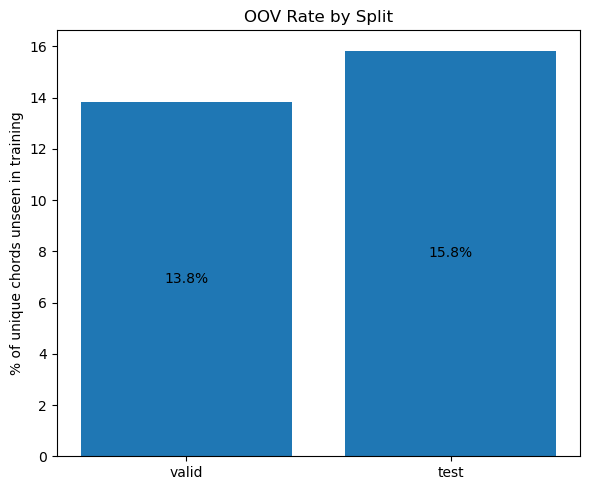

In [33]:
train_chord_set = set(chord for seq in train for _, chord in seq)
oov_stats = {}

for split in ['valid', 'test']:
    split_seqs = parsed[split]
    unique = set(chord for seq in split_seqs for _, chord in seq)
    unseen = unique - train_chord_set
    oov_stats[split] = {'unique': len(unique), 'unseen': len(unseen)}
    pct = len(unseen) / len(unique) * 100 if unique else 0
    print(f"  {split}: {len(unique)} unique chords, {len(unseen)} unseen ({pct:.1f}%)")

oov_splits = ['valid', 'test']
oov_pcts   = [
    oov_stats[s]['unseen'] / oov_stats[s]['unique'] * 100 if oov_stats[s]['unique'] else 0
    for s in oov_splits
]

_, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(oov_splits, oov_pcts)
for bar, pct in zip(bars, oov_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
            f'{pct:.1f}%', ha='center', va='center')
ax.set_ylabel('% of unique chords unseen in training')
ax.set_title('OOV Rate by Split')
plt.tight_layout()
plt.savefig('task2/eda_plots/oov_chords.png')
plt.show()

## 6. Baseline

In [34]:
def evaluate_baseline(encoded_data, idx_to_note, idx_to_chord):
    """For each melody note, predict its most common training chord; evaluate on test set."""
    print("Evaluating baseline...")

    train_pairs = collections.defaultdict(list)
    for seq in encoded_data['train']:
        for note_idx, chord_idx in seq:
            train_pairs[note_idx].append(chord_idx)

    overall_chord_counts  = collections.Counter(
        chord_idx for chords in train_pairs.values() for chord_idx in chords
    )
    most_common_chord_idx = overall_chord_counts.most_common(1)[0][0]

    note_to_best_chord = {}
    note_support       = {}
    for note_idx, chords in train_pairs.items():
        note_to_best_chord[note_idx] = collections.Counter(chords).most_common(1)[0][0]
        note_support[note_idx]       = len(chords)

    correct = 0
    total   = 0
    for seq in encoded_data['test']:
        for note_idx, chord_idx in seq:
            pred = note_to_best_chord.get(note_idx, most_common_chord_idx)
            if pred == chord_idx:
                correct += 1
            total += 1

    baseline_accuracy = correct / total

    top10_notes = sorted(note_support, key=note_support.get, reverse=True)[:10]
    df = pd.DataFrame({
        'melody_note':      [idx_to_note.get(n, n) for n in top10_notes],
        'most_common_chord': [str(set(idx_to_chord.get(note_to_best_chord[n], {}))) for n in top10_notes],
        'support':          [note_support[n] for n in top10_notes],
    })
    display(df)
    print(f"\nPer-note majority baseline accuracy on test set: {baseline_accuracy:.4f} ({correct}/{total} timesteps)")

    return baseline_accuracy, most_common_chord_idx


baseline_accuracy, most_common_chord_idx = evaluate_baseline(encoded, idx_to_note, idx_to_chord)

Evaluating baseline...


,melody_note,most_common_chord,support
0,69,"{66, 50, 62}",9096
1,71,"{67, 62, 55}",6940
2,74,"{57, 66, 50}",6776
3,72,"{65, 53, 57}",6071
4,67,"{43, 59, 62}",5927
5,76,"{59, 67, 52}",3269
6,70,"{67, 62, 55}",3011
7,73,"{64, 57, 69}",2588
8,64,"{56, 59, 52}",2203
9,65,"{57, 60, 41}",1876



Per-note majority baseline accuracy on test set: 0.0991 (1865/18820 timesteps)


## 7. Save Processed Data

In [35]:
def save_processed_data(encoded_data, note_to_idx, idx_to_note, chord_to_idx,
                        idx_to_chord, baseline_accuracy, most_common_chord_idx):
    """Save all preprocessed data and vocabularies to a single pickle file."""
    print("Saving processed data...")

    payload = {
        'encoded_data': encoded_data,
        'note_to_idx': note_to_idx,
        'idx_to_note': idx_to_note,
        'chord_to_idx': chord_to_idx,
        'idx_to_chord': idx_to_chord,
        'baseline_accuracy': baseline_accuracy,
        'most_common_chord_idx':  most_common_chord_idx,
        'vocab_sizes': {
            'note':  len(note_to_idx),
            'chord': len(chord_to_idx),
        },
    }

    out_path = 'task2/processed_data.pkl'
    os.makedirs('task2', exist_ok=True)
    with open(out_path, 'wb') as f:
        pickle.dump(payload, f)

    size_kb = os.path.getsize(out_path) / 1024
    print(f"Saved {out_path}  ({size_kb:.1f} KB)")


save_processed_data(encoded, note_to_idx, idx_to_note, chord_to_idx, idx_to_chord, baseline_accuracy, most_common_chord_idx)

Saving processed data...
Saved task2/processed_data.pkl  (644.8 KB)


In [36]:
def load_processed_data():
    """Load and return the preprocessed data dict from processed_data.pkl."""
    with open('task2/processed_data.pkl', 'rb') as f:
        data = pickle.load(f)
    print("Loaded processed data from processed_data.pkl")
    return data

# data = load_processed_data()

# Task 2: Symbolic Conditioned Generation

## 1. Imports & Configuration

In [45]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Hyperparameters
EMBED_DIM     = 64
HIDDEN_DIM    = 256
NUM_LAYERS    = 2
DROPOUT       = 0.5
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
NUM_EPOCHS    = 120
PATIENCE      = 10

# Paths
DATA_PATH  = 'task2/processed_data.pkl'
OUTPUT_DIR = 'task2/model_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Using device: cuda


## 2. Data Augmentation

In [46]:
def augment_by_transposition(encoded_sequences, idx_to_note, note_to_idx,
                              idx_to_chord, chord_to_idx):
    """Augments training data by transposing chorales into different keys (-5 to +6 semitones)."""
    augmented = list(encoded_sequences)
    for shift in range(-5, 7):
        if shift == 0:
            continue
        for seq in encoded_sequences:
            transposed_seq = []
            valid = True
            for note_idx, chord_idx in seq:
                orig_note = idx_to_note.get(note_idx)
                if orig_note is None or not isinstance(orig_note, int):
                    valid = False; break
                new_note_idx = note_to_idx.get(orig_note + shift)
                if new_note_idx is None:
                    valid = False; break
                orig_chord = idx_to_chord.get(chord_idx)
                if orig_chord is None or not isinstance(orig_chord, frozenset):
                    valid = False; break
                new_chord_idx = chord_to_idx.get(frozenset(p + shift for p in orig_chord))
                if new_chord_idx is None:
                    valid = False; break
                transposed_seq.append((new_note_idx, new_chord_idx))
            if valid and len(transposed_seq) == len(seq):
                augmented.append(transposed_seq)
    return augmented

## 3. DataLoader

In [47]:
class ChoraleDataset(Dataset):
    """Stores melodies (inputs) and chords (targets) as tensors."""
    def __init__(self, encoded_sequences):
        self.melodies = []
        self.chords   = []
        for seq in encoded_sequences:
            self.melodies.append(torch.tensor([p[0] for p in seq], dtype=torch.long))
            self.chords.append(  torch.tensor([p[1] for p in seq], dtype=torch.long))
    def __len__(self):          return len(self.melodies)
    def __getitem__(self, idx): return self.melodies[idx], self.chords[idx]

def collate_fn(batch):
    """Pads a batch to uniform length."""
    melodies, chords = zip(*batch)
    lengths = torch.tensor([len(m) for m in melodies], dtype=torch.long)
    return (
        pad_sequence(melodies, batch_first=True, padding_value=0),
        pad_sequence(chords,   batch_first=True, padding_value=-1),
        lengths,
    )

## 4. Model

In [48]:
class MelodyToChordLSTM(nn.Module):
    """Bidirectional LSTM predicting the accompanying chord at each melody timestep."""
    def __init__(self, note_vocab_size, chord_vocab_size, embed_dim, hidden_dim,
                 num_layers, dropout):
        super().__init__()
        self.embedding      = nn.Embedding(note_vocab_size, embed_dim, padding_idx=0)
        self.embed_dropout  = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.output_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, chord_vocab_size)  # *2 for bidirectional

    def forward(self, melodies, lengths):
        x = self.embed_dropout(self.embedding(melodies))              # (B, T, E)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(out, batch_first=True)      # (B, T, 2H)
        logits = self.fc(self.output_dropout(lstm_out))                # (B, T, chord_vocab)
        return logits

## 5. Training & Evaluation Helpers

In [49]:
def train_one_epoch(model, loader, optimizer, criterion):
    """One training epoch; returns average loss per token."""
    model.train()
    total_loss, total_tokens = 0.0, 0
    for melodies, chords, lengths in loader:
        melodies, chords, lengths = melodies.to(DEVICE), chords.to(DEVICE), lengths.to(DEVICE)
        optimizer.zero_grad()
        logits = model(melodies, lengths)
        loss = criterion(logits.view(-1, logits.size(-1)), chords.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        n = (chords != -1).sum().item()
        total_loss += loss.item() * n
        total_tokens += n
    return total_loss / total_tokens


def partial_similarity(set_a, set_b):
    """Jaccard similarity between two chord sets."""
    if not set_a and not set_b: return 1.0
    union = len(set_a | set_b)
    return len(set_a & set_b) / union if union > 0 else 0.0


def evaluate(model, loader, criterion, idx_to_chord=None):
    """Returns (avg_loss, exact_accuracy, partial_match_accuracy)."""
    model.eval()
    total_loss, total_tokens, correct, partial_sum = 0.0, 0, 0, 0.0
    with torch.no_grad():
        for melodies, chords, lengths in loader:
            melodies, chords, lengths = melodies.to(DEVICE), chords.to(DEVICE), lengths.to(DEVICE)
            logits = model(melodies, lengths)
            logits_flat = logits.view(-1, logits.size(-1))
            chords_flat = chords.view(-1)
            loss = criterion(logits_flat, chords_flat)
            mask = (chords_flat != -1)
            preds = logits_flat.argmax(dim=-1)
            correct += (preds[mask] == chords_flat[mask]).sum().item()
            if idx_to_chord is not None:
                for p, t in zip(preds[mask].cpu().numpy(), chords_flat[mask].cpu().numpy()):
                    pc = set(idx_to_chord.get(int(p), frozenset()))
                    tc = set(idx_to_chord.get(int(t), frozenset()))
                    partial_sum += partial_similarity(pc, tc)
            n = mask.sum().item()
            total_loss += loss.item() * n
            total_tokens += n
    return total_loss / total_tokens, correct / total_tokens, \
           partial_sum / total_tokens if idx_to_chord is not None else None

## 6. Full Training Loop

In [50]:
def train_model(model, train_loader, val_loader, num_epochs, learning_rate, patience):
    """Training with early stopping and LR scheduling; restores the best checkpoint."""
    criterion = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_loss, best_epoch, epochs_no_improve, best_state = float('inf'), 0, 0, None

    print(f'Training on {DEVICE} for up to {num_epochs} epochs (patience={patience})')
    print(f'{"Epoch":>5}  {"Train Loss":>10}  {"Val Loss":>10}  '
          f'{"Train Acc":>10}  {"Val Acc":>10}  {"LR":>10}')

    for epoch in range(1, num_epochs + 1):
        train_loss             = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _   = evaluate(model, val_loader, criterion)
        _, train_acc, _        = evaluate(model, train_loader, criterion)
        current_lr             = optimizer.param_groups[0]['lr']
        for k, v in zip(['train_loss','val_loss','train_acc','val_acc','lr'],
                        [train_loss,  val_loss,  train_acc,  val_acc,  current_lr]):
            history[k].append(v)
        print(f'{epoch:5d}  {train_loss:10.4f}  {val_loss:10.4f}  '
              f'{train_acc:10.4f}  {val_acc:10.4f}  {current_lr:10.6f}')
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss, best_epoch, epochs_no_improve = val_loss, epoch, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping at epoch {epoch} (best was epoch {best_epoch})')
            break
    if best_state:
        model.load_state_dict(best_state); model.to(DEVICE)
        print(f'Restored best model from epoch {best_epoch} (val_loss={best_val_loss:.4f})')
    return history

## 7. Plot Training Curves

In [51]:
def plot_training_curves(history, baseline_accuracy):
    """Saves loss, accuracy, and learning-rate plots to OUTPUT_DIR."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, history['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(epochs, history['val_loss'],   label='Validation Loss', linewidth=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
    ax.set_title('Training and Validation Loss'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curves.png'), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, history['train_acc'], label='Train Accuracy', linewidth=2)
    ax.plot(epochs, history['val_acc'],   label='Validation Accuracy', linewidth=2)
    ax.axhline(y=baseline_accuracy, color='r', linestyle='--', linewidth=1.5,
               label=f'Baseline ({baseline_accuracy:.2%})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Chord Accuracy')
    ax.set_title('Chord Prediction Accuracy vs. Baseline'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'accuracy_curves.png'), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(epochs, history['lr'], linewidth=2, color='green')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'lr_schedule.png'), dpi=150); plt.show()
    print(f'Saved plots to {OUTPUT_DIR}/')

## 8. MIDI Generation

In [52]:
def generate_midi(model, test_dataset, idx_to_note, idx_to_chord, num_chorales=3):
    """Predicts chords for test chorales and writes playable MIDI files."""
    try:
        from midiutil import MIDIFile
    except ImportError:
        print('midiutil not installed — skipping MIDI generation'); return

    model.eval()
    midi_dir = os.path.join(OUTPUT_DIR, 'midi')
    os.makedirs(midi_dir, exist_ok=True)
    n = min(num_chorales, len(test_dataset))

    for i in range(n):
        melody_tensor, _ = test_dataset[i]
        length = torch.tensor([len(test_dataset.melodies[i])], dtype=torch.long)
        with torch.no_grad():
            logits = model(melody_tensor.unsqueeze(0).to(DEVICE), length)
            pred_indices = logits.argmax(dim=-1).squeeze(0).cpu().numpy()

        midi = MIDIFile(1)
        midi.addTempo(0, 0, 120)
        time_per_step = 0.25  # 16th notes @ 120 BPM
        for t in range(length.item()):
            note_val = idx_to_note.get(test_dataset.melodies[i][t].item())
            if isinstance(note_val, int):
                midi.addNote(0, 0, note_val, t * time_per_step, time_per_step, volume=100)
            chord_val = idx_to_chord.get(int(pred_indices[t]))
            if isinstance(chord_val, frozenset):
                for pitch in sorted(chord_val):
                    if isinstance(pitch, int):
                        midi.addNote(0, 0, pitch, t * time_per_step, time_per_step, volume=80)
        out_path = os.path.join(midi_dir, f'chorale_pred_{i+1}.mid')
        with open(out_path, 'wb') as f:
            midi.writeFile(f)
        print(f'Saved {out_path}')
    print(f'Generated {n} MIDI files in {midi_dir}/')

## 9. Final Evaluation

In [53]:
def final_evaluation(model, test_loader, baseline_accuracy, idx_to_chord):
    """Prints test metrics and saves a comparison bar chart."""
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    test_loss, test_acc, partial_acc = evaluate(model, test_loader, criterion, idx_to_chord)

    print('Final Test Set Evaluation')
    print(f'  Baseline accuracy:         {baseline_accuracy:.4f}  ({baseline_accuracy:.2%})')
    print(f'  LSTM exact match:          {test_acc:.4f}  ({test_acc:.2%})')
    print(f'  LSTM partial match:        {partial_acc:.4f}  ({partial_acc:.2%})')
    print(f'  LSTM test loss:            {test_loss:.4f}')
    improvement = test_acc - baseline_accuracy
    print(f'  Improvement over baseline: {improvement:+.4f}  ({improvement:+.2%})')
    print('  LSTM beats baseline' if test_acc > baseline_accuracy else '  LSTM does not beat baseline')

    fig, ax = plt.subplots(figsize=(8, 5))
    labels = ['Baseline\n(Exact Match)', 'LSTM\n(Exact Match)', 'LSTM\n(Partial Match)']
    accs   = [baseline_accuracy, test_acc, partial_acc]
    colors = ['#d9534f', '#5cb85c', '#337ab7']
    bars   = ax.bar(labels, accs, color=colors, width=0.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{acc:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylabel('Chord Accuracy')
    ax.set_title('Test Accuracy: Baseline vs LSTM (Exact & Partial Match)')
    ax.set_ylim(0, max(accs) * 1.3); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'test_accuracy_comparison.png'), dpi=150); plt.show()
    return test_acc, test_loss, partial_acc

## 10. Run: Load Data → Build Model → Train → Evaluate → Save

Note vocab:        24
Chord vocab:       1660
Baseline accuracy: 0.0991
Augmentation: 229 -> 328 training chorales
Train: 328  |  Valid: 76  |  Test: 77
Model params: 3,089,532 total, 3,089,532 trainable
MelodyToChordLSTM(
  (embedding): Embedding(24, 64, padding_idx=0)
  (embed_dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (output_dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=1660, bias=True)
)


Training on cuda for up to 120 epochs (patience=10)
Epoch  Train Loss    Val Loss   Train Acc     Val Acc          LR


    1      6.9861      6.3589      0.0531      0.0501    0.001000


    2      6.0426      5.9378      0.0975      0.0943    0.001000


    3      5.6665      5.6713      0.1269      0.1181    0.001000


...

   32      3.5272      4.7809      0.4195      0.1984    0.001000


   33      3.4881      4.7807      0.4278      0.1987    0.001000


   34      3.4457      4.7792      0.4363      0.1982    0.001000


   35      3.4199      4.7832      0.4473      0.1997    0.001000


   36      3.3643      4.7863      0.4558      0.2029    0.000500
Early stopping at epoch 36 (best was epoch 26)
Restored best model from epoch 26 (val_loss=4.7579)


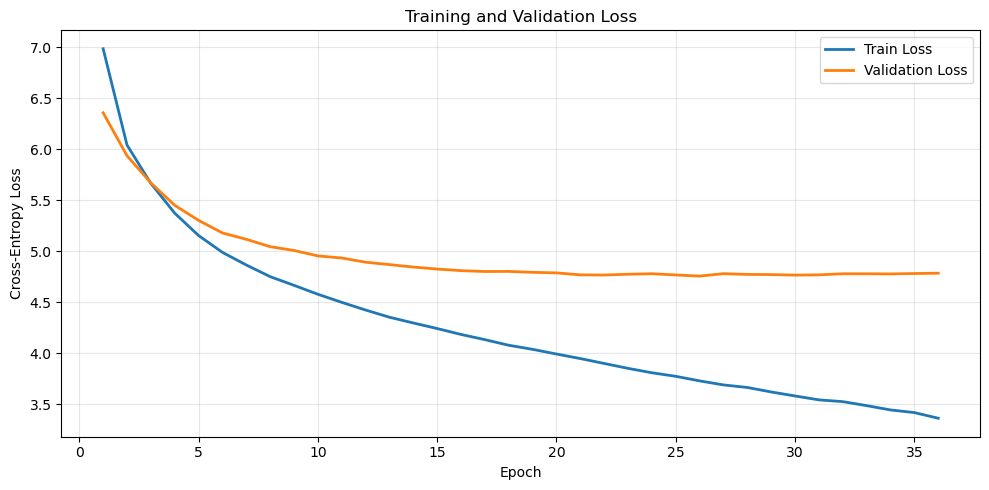

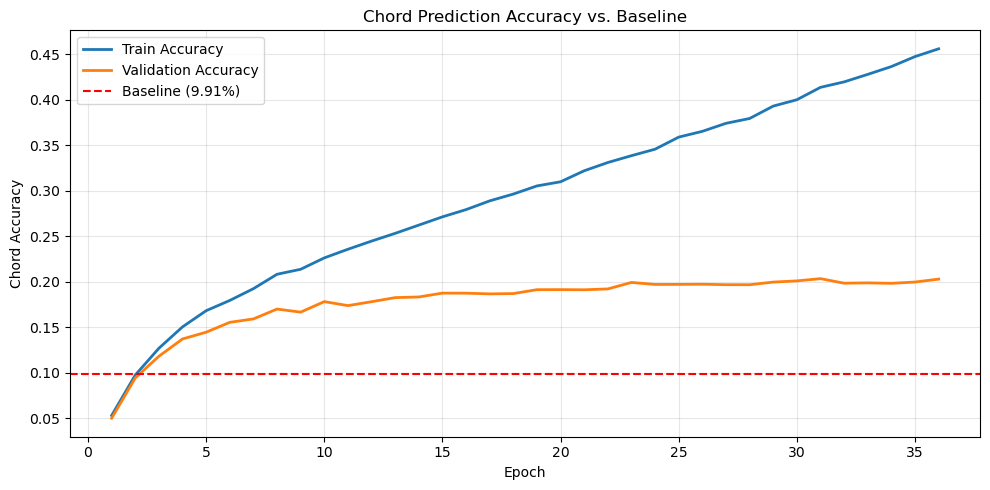

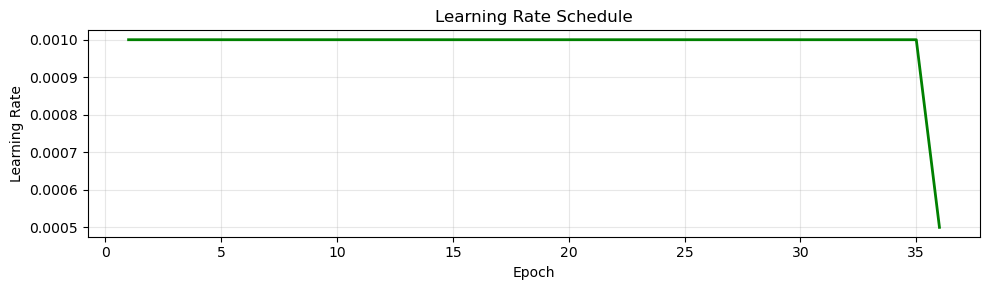

Saved plots to task2/model_output/
Final Test Set Evaluation
  Baseline accuracy:         0.0991  (9.91%)
  LSTM exact match:          0.2072  (20.72%)
  LSTM partial match:        0.3913  (39.13%)
  LSTM test loss:            4.2069
  Improvement over baseline: +0.1081  (+10.81%)
  LSTM beats baseline


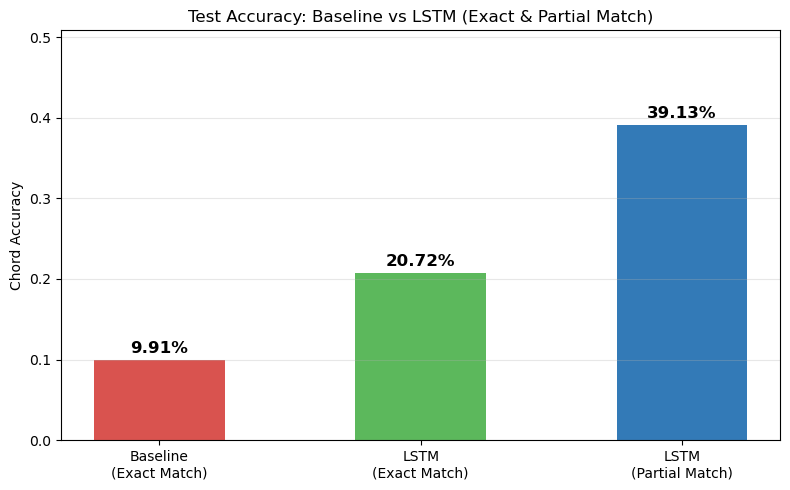

Generating MIDI output from test set predictions...
Saved task2/model_output/midi/chorale_pred_1.mid


Saved task2/model_output/midi/chorale_pred_2.mid
Saved task2/model_output/midi/chorale_pred_3.mid
Generated 3 MIDI files in task2/model_output/midi/
Saved trained model to task2/model_output/lstm_model.pt


In [54]:
# Load processed data
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

note_to_idx           = data['note_to_idx']
idx_to_note           = data['idx_to_note']
chord_to_idx          = data['chord_to_idx']
idx_to_chord          = data['idx_to_chord']
baseline_accuracy     = data['baseline_accuracy']
most_common_chord_idx = data['most_common_chord_idx']
note_vocab_size       = data['vocab_sizes']['note']
chord_vocab_size      = data['vocab_sizes']['chord']

print(f'Note vocab:        {note_vocab_size}')
print(f'Chord vocab:       {chord_vocab_size}')
print(f'Baseline accuracy: {baseline_accuracy:.4f}')

# Augment training data
orig_count      = len(data['encoded_data']['train'])
augmented_train = augment_by_transposition(
    data['encoded_data']['train'], idx_to_note, note_to_idx, idx_to_chord, chord_to_idx)
print(f'Augmentation: {orig_count} -> {len(augmented_train)} training chorales')

# Datasets and loaders
train_dataset = ChoraleDataset(augmented_train)
val_dataset   = ChoraleDataset(data['encoded_data']['valid'])
test_dataset  = ChoraleDataset(data['encoded_data']['test'])
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           collate_fn=collate_fn, drop_last=False)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                           collate_fn=collate_fn, drop_last=False)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                           collate_fn=collate_fn, drop_last=False)
print(f'Train: {len(train_dataset)}  |  Valid: {len(val_dataset)}  |  Test: {len(test_dataset)}')

# Build model
model = MelodyToChordLSTM(
    note_vocab_size=note_vocab_size, chord_vocab_size=chord_vocab_size,
    embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS, dropout=DROPOUT,
).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model params: {total:,} total, {trainable:,} trainable')
print(model)

# Train
history = train_model(model, train_loader, val_loader,
                      num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, patience=PATIENCE)
plot_training_curves(history, baseline_accuracy)

# Evaluate on test set
test_acc, test_loss, partial_acc = final_evaluation(
    model, test_loader, baseline_accuracy, idx_to_chord)

# Generate MIDI files
print('Generating MIDI output from test set predictions...')
generate_midi(model, test_dataset, idx_to_note, idx_to_chord, num_chorales=3)

# Save model checkpoint
model_path = os.path.join(OUTPUT_DIR, 'lstm_model.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'hyperparameters':  {'embed_dim': EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
                         'num_layers': NUM_LAYERS, 'dropout': DROPOUT},
    'note_vocab_size':  note_vocab_size,
    'chord_vocab_size': chord_vocab_size,
    'test_accuracy':    test_acc,
    'baseline_accuracy': baseline_accuracy,
    'history':          history,
}, model_path)
print(f'Saved trained model to {model_path}')